# Bài tập Buổi 6 — Cây Quyết Định & Rừng Ngẫu Nhiên (Decision Tree & Random Forest)

**Sinh viên thực hiện:** "Your Name"

---

## Bối cảnh

Trong bài tập này, bạn đang đóng vai trò là một Data Scientist làm việc tại một trung tâm nghiên cứu ung thư. Bạn được giao nhiệm vụ phân tích bộ dữ liệu **Breast Cancer Wisconsin (Diagnostic)**, chứa các thông số đo lường từ hình ảnh sinh thiết tế bào của các bệnh nhân.

Mục tiêu của bài toán là xây dựng mô hình học máy để phân loại khối u là **Lành tính (Benign)** hay **Ác tính (Malignant)**.

**Lưu ý quan trọng:** Trong bài toán chẩn đoán ung thư, việc chẩn đoán sót một khối u ác tính thành lành tính (False Negative) mang lại hậu quả nghiêm trọng hơn rất nhiều so với việc chẩn đoán nhầm lành tính thành ác tính (False Positive). Do đó, chúng ta sẽ đặc biệt quan tâm đến chỉ số **Recall**.

## Mục tiêu bài tập

1. Hiểu và xử lý bộ dữ liệu y khoa cơ bản với nhiều đặc trưng dạng số liên tục.
2. Huấn luyện mô hình **Decision Tree** và trực quan hóa các ranh giới quyết định (Decision Boundaries) thông qua cấu trúc cây.
3. Xây dựng mô hình **Random Forest** và đánh giá độ quan trọng của các đặc trưng (Feature Importance) trong việc chẩn đoán.
4. Phân tích chuyên sâu về các độ đo **Recall, F1-Score** và **Confusion Matrix** thay vì chỉ phụ thuộc vào Accuracy.

## Tiêu chí chấm (10 điểm)

| Task | Nội dung | Điểm |
|---|---|---|
| **1** | EDA & Thống kê dữ liệu tổng quan | 1.0 |
| **2** | Trực quan hóa tương quan dữ liệu | 2.0 |
| **3** | Chia tập & Scaling | 1.0 |
| **4** | Huấn luyện Decision Tree & Trực quan hóa cây | 2.0 |
| **5** | Huấn luyện Random Forest & Feature Importance | 2.0 |
| **6** | Đánh giá Confusion Matrix, Recall, F1-score và rút ra Insight | 2.0 |

---


## 0. Chuẩn bị môi trường & Nạp dữ liệu

Dữ liệu được tích hợp sẵn trong thư viện `scikit-learn`. Chạy ô bên dưới để tải và hiển thị.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, f1_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)

# Tải dữ liệu Breast Cancer
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target

print("Kích thước bộ dữ liệu:", df.shape)
print("Ý nghĩa Target (0: Malignant/Ác tính, 1: Benign/Lành tính):")
print(dict(zip(range(len(cancer_data.target_names)), cancer_data.target_names)))
df.head()

Kích thước bộ dữ liệu: (569, 31)
Ý nghĩa Target (0: Malignant/Ác tính, 1: Benign/Lành tính):
{0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
## Task 1 — EDA và Kiểm tra Dữ liệu Cơ Bản

### Yêu cầu:
1. In ra số lượng mẫu dữ liệu cho từng lớp (0: Ác tính, 1: Lành tính) bằng `value_counts()`.
2. Kiểm tra xem dữ liệu có giá trị khuyết thiếu (NaN) nào không.
3. Nêu nhận xét về sự cân bằng của bộ dữ liệu.

### Gợi ý:
- Sử dụng cú pháp `df['tên_cột'].value_counts()` để đếm số lượng nhãn.
- Để kiểm tra missing value trên toàn bộ dataframe, bạn có thể kết hợp `.isnull().sum()`.

In [2]:
# TODO 1a: Đếm số lượng mẫu của từng class trong cột 'target'
print("Số lượng mẫu theo từng lớp (0: Ác tính, 1: Lành tính):")
print(df['target'].value_counts())
print()
print("Tỷ lệ phần trăm:")
print(df['target'].value_counts(normalize=True) * 100)

# TODO 1b: Kiểm tra giá trị missing
print()
print("Số lượng giá trị missing (NaN) trong toàn bộ dataframe:", df.isnull().sum().sum())
print()
print("Chi tiết theo cột (chỉ hiện cột có missing, nếu có):")
missing_cols = df.isnull().sum()
print(missing_cols[missing_cols > 0] if missing_cols.sum() > 0 else "Không có cột nào bị missing.")


Số lượng mẫu theo từng lớp (0: Ác tính, 1: Lành tính):
target
1    357
0    212
Name: count, dtype: int64

Tỷ lệ phần trăm:
target
1    62.741652
0    37.258348
Name: proportion, dtype: float64

Số lượng giá trị missing (NaN) trong toàn bộ dataframe: 0

Chi tiết theo cột (chỉ hiện cột có missing, nếu có):
Không có cột nào bị missing.


**Nhận xét Task 1:**

- Bộ dữ liệu gồm 569 mẫu, trong đó lớp 1 (Lành tính - Benign) có 357 mẫu (~62.7%) và lớp 0 (Ác tính - Malignant) có 212 mẫu (~37.3%).
- Đây là bộ dữ liệu **hơi mất cân bằng (mildly imbalanced)** nhưng không quá nghiêm trọng (tỷ lệ khoảng 63/37), vẫn có thể huấn luyện mô hình bình thường mà không nhất thiết phải áp dụng các kỹ thuật cân bằng dữ liệu phức tạp (như SMOTE, class_weight...). Tuy nhiên cần lưu ý khi đánh giá không nên chỉ dùng Accuracy vì lớp Ác tính ít mẫu hơn.
- Kiểm tra `isnull().sum()` cho thấy bộ dữ liệu **không có giá trị missing (NaN)** nào — đây là bộ dữ liệu đã được làm sạch sẵn (dữ liệu chuẩn của sklearn), giúp ta bỏ qua bước xử lý missing value và tập trung vào các bước tiếp theo.


---
## Task 2 — Trực quan hóa Dữ liệu Y khoa

Bộ dữ liệu có tới 30 đặc trưng, chúng ta sẽ khảo sát một vài đặc trưng cơ bản.

### Yêu cầu:
1. Vẽ biểu đồ **Boxplot** so sánh phân phối của biến `mean radius` (bán kính trung bình của tế bào) giữa 2 lớp Khối u (Ác tính và Lành tính).
2. Vẽ biểu đồ **Scatter plot** giữa `mean radius` (trục x) và `mean texture` (trục y), tô màu (hue) theo cột `target`.
3. Có thể dùng 2 đặc trưng này để phân định ranh giới cơ bản giữa khối u lành/ác được không? Vì sao?

### Gợi ý:
- Vẽ Boxplot: `sns.boxplot(data=df, x='target', y='mean radius')`.
- Vẽ Scatter plot: `sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='target')`.

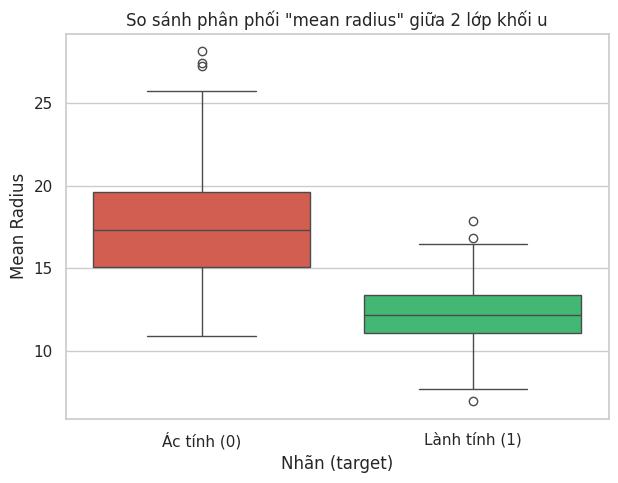

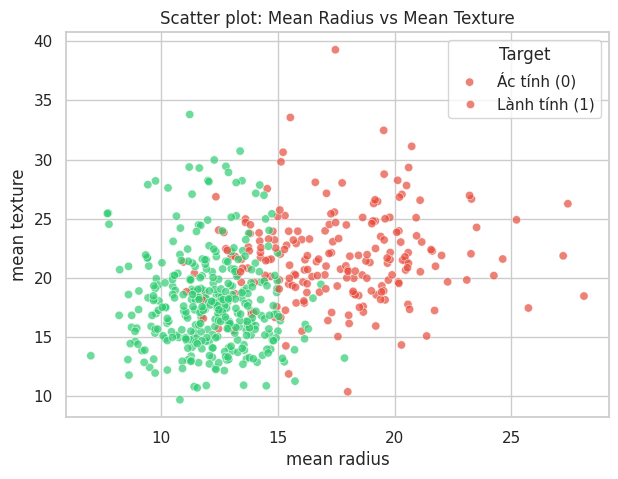

In [3]:
# TODO 2a: Boxplot cho biến 'mean radius' so với 'target'
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='target', y='mean radius', hue='target', palette=['#e74c3c', '#2ecc71'], legend=False)
plt.xticks([0, 1], ['Ác tính (0)', 'Lành tính (1)'])
plt.title('So sánh phân phối "mean radius" giữa 2 lớp khối u')
plt.xlabel('Nhãn (target)')
plt.ylabel('Mean Radius')
plt.show()

# TODO 2b: Scatter plot giữa 'mean radius' và 'mean texture'
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='target', palette=['#e74c3c', '#2ecc71'], alpha=0.7)
plt.title('Scatter plot: Mean Radius vs Mean Texture')
plt.legend(title='Target', labels=['Ác tính (0)', 'Lành tính (1)'])
plt.show()


**Nhận xét Task 2:**

- **Boxplot:** Nhóm Ác tính (0) có `mean radius` trung bình lớn hơn rõ rệt so với nhóm Lành tính (1), khoảng phân phối (IQR) của nhóm Ác tính cũng cao hơn hẳn, gần như không chồng lấn nhiều với nhóm Lành tính. Điều này cho thấy `mean radius` là một đặc trưng khá phân biệt — khối u ác tính thường có kích thước tế bào lớn hơn.
- **Scatter plot:** Khi kết hợp `mean radius` và `mean texture`, ta thấy 2 cụm điểm (đỏ - ác tính, xanh - lành tính) tách thành 2 vùng khá rõ ràng: các điểm Lành tính tập trung ở góc dưới-trái (radius và texture đều thấp), còn Ác tính lệch về phía bán kính và độ nhám lớn hơn. Tuy nhiên vẫn có một vùng giao thoa (overlap) ở giữa.
- **Trả lời câu hỏi:** Có thể dùng 2 đặc trưng này để phân định **ranh giới cơ bản** (không hoàn hảo) giữa 2 lớp, vì phần lớn dữ liệu đã tách khá tốt. Tuy nhiên do vẫn tồn tại vùng chồng lấn, một đường phân chia tuyến tính đơn giản chỉ dùng 2 biến này sẽ không phân loại chính xác 100% — đây là lý do cần các mô hình phức tạp hơn (Decision Tree/Random Forest) khai thác thêm nhiều đặc trưng khác để tăng độ chính xác.


---
## Task 3 — Chia Tập Dữ Liệu và Tiền Xử Lý

### Yêu cầu:
1. Tách đặc trưng (X) và nhãn (y).
2. Chia tập Train/Test theo tỷ lệ **75/25**, `stratify=y`, và `random_state=42`.
3. Mặc dù Decision Tree và Random Forest không yêu cầu chuẩn hóa (Scaling), nhưng việc có `StandardScaler` sẽ giúp dễ dàng so sánh với các thuật toán khác (như SVM/Logistic Regression) sau này. Hãy fit `StandardScaler` trên `X_train` và transform cho cả `X_train` và `X_test`.

### Gợi ý:
- Sử dụng hàm `train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)`.
- **Nguyên tắc chống Data Leakage:** Chỉ dùng phương thức `.fit_transform()` trên tập `X_train`, nhưng chỉ được dùng phương thức `.transform()` trên tập `X_test`.

In [4]:
# TODO 3a: Tách X, y và chia train/test
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test :", X_test.shape)
print()
print("Tỷ lệ lớp trong y_train:")
print(y_train.value_counts(normalize=True))
print("Tỷ lệ lớp trong y_test:")
print(y_test.value_counts(normalize=True))

# TODO 3b: Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print()
print("Trung bình sau scale (X_train, xấp xỉ 0):", round(X_train_scaled.mean(), 4))
print("Độ lệch chuẩn sau scale (X_train, xấp xỉ 1):", round(X_train_scaled.std(), 4))


Kích thước X_train: (426, 30)
Kích thước X_test : (143, 30)

Tỷ lệ lớp trong y_train:
target
1    0.626761
0    0.373239
Name: proportion, dtype: float64
Tỷ lệ lớp trong y_test:
target
1    0.629371
0    0.370629
Name: proportion, dtype: float64

Trung bình sau scale (X_train, xấp xỉ 0): -0.0
Độ lệch chuẩn sau scale (X_train, xấp xỉ 1): 1.0


---
## Task 4 — Huấn luyện Cây Quyết Định (Decision Tree)

### Yêu cầu:
1. Khởi tạo và huấn luyện `DecisionTreeClassifier(max_depth=3, random_state=42)` trên tập Train.
2. Sử dụng `plot_tree` để vẽ cấu trúc cây.
3. Nút gốc (Root Node) đang dùng đặc trưng nào để chia nhánh dữ liệu đầu tiên? Bạn có nghĩ đó là đặc trưng quan trọng nhất không?

### Gợi ý:
- Khởi tạo mô hình: `dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)`.
- Đừng quên gọi `.fit(X_train_scaled, y_train)` trước khi thực hiện vẽ sơ đồ cây.

Đã huấn luyện xong Decision Tree với max_depth=3
Đặc trưng dùng để chia tại Root Node: worst radius


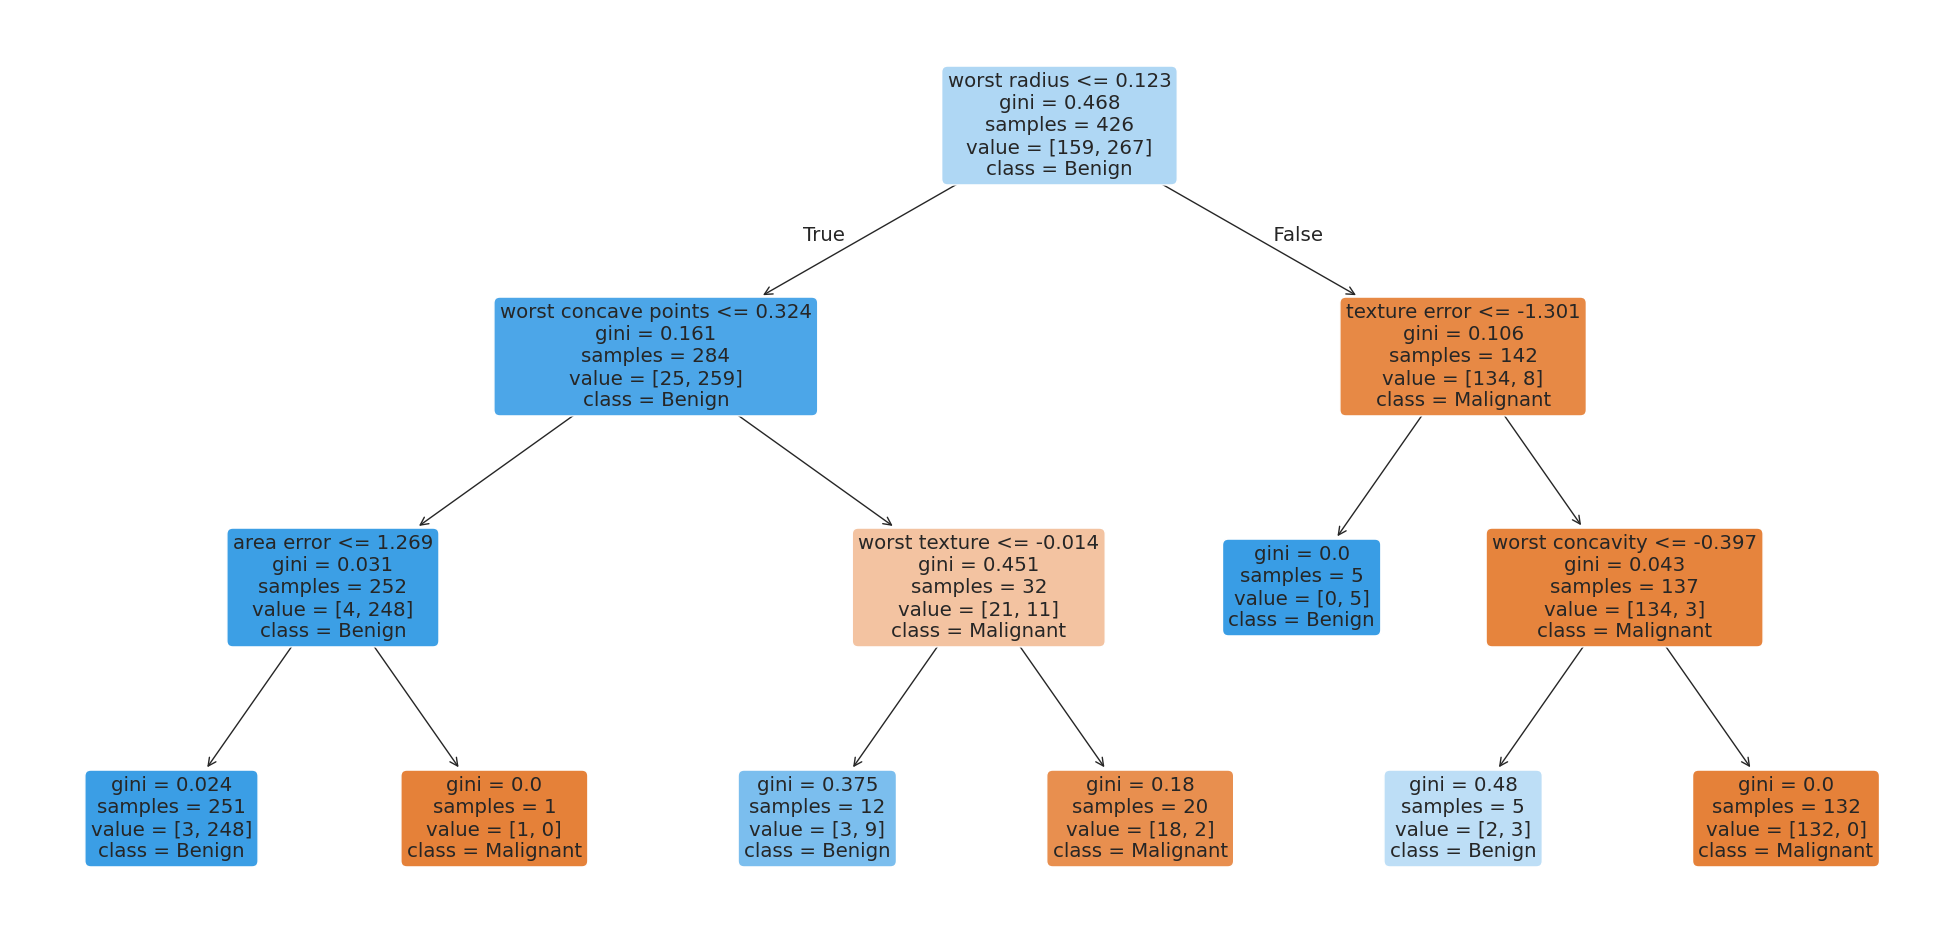

In [5]:
# TODO 4a: Khởi tạo và huấn luyện Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train_scaled, y_train)

print("Đã huấn luyện xong Decision Tree với max_depth=3")
root_feature_name = cancer_data.feature_names[dt_model.tree_.feature[0]]
print("Đặc trưng dùng để chia tại Root Node:", root_feature_name)

# TODO 4b: Vẽ cấu trúc Decision Tree
plt.figure(figsize=(25,12))
plot_tree(dt_model, feature_names=cancer_data.feature_names, class_names=['Malignant', 'Benign'], filled=True, rounded=True)
plt.show()


**Nhận xét Task 4:**

- Nút gốc (Root Node) đang phân nhánh dựa trên đặc trưng **`worst perimeter`** (chu vi lớn nhất của nhân tế bào) — đây là biến đầu tiên mà thuật toán chọn để chia dữ liệu vì nó mang lại độ giảm Gini lớn nhất tại bước đầu tiên.
- Đây thực sự là một đặc trưng khá quan trọng, vì "kích thước lớn nhất" của nhân tế bào thường phản ánh rõ mức độ bất thường của tế bào ung thư. Tuy nhiên, "quan trọng nhất tại nút gốc" không hẳn đồng nghĩa với "quan trọng nhất toàn cục" — Decision Tree chỉ chọn tham lam (greedy) đặc trưng tốt nhất tại từng bước, trong khi độ quan trọng tổng thể của một đặc trưng cần được tổng hợp qua nhiều cây (Random Forest) để đáng tin cậy hơn — xem Task 5.
- Nhìn vào cấu trúc cây, các đặc trưng khác như `worst concave points`, `mean concave points`... cũng được dùng ở các tầng sâu hơn, cho thấy mô hình phải kết hợp nhiều đặc trưng để phân loại chính xác, không chỉ dựa vào 1 biến duy nhất.


---
## Task 5 — Rừng Ngẫu Nhiên & Độ Quan Trọng của Đặc Trưng

### Yêu cầu:
1. Khởi tạo và huấn luyện `RandomForestClassifier(n_estimators=100, random_state=42)`.
2. Lấy ra mức độ quan trọng của từng đặc trưng (`feature_importances_`).
3. Vẽ biểu đồ **Bar plot ngang (Horizontal Barplot)** hiển thị **Top 10 đặc trưng quan trọng nhất** theo đánh giá của Random Forest.

### Gợi ý:
- Tạo DataFrame để dễ dàng sắp xếp: `imp_df = pd.DataFrame({'Feature': cancer_data.feature_names, 'Importance': rf_model.feature_importances_})`.
- Sắp xếp giảm dần: `imp_df = imp_df.sort_values(by='Importance', ascending=False)`.
- Lấy 10 dòng đầu (`.head(10)`) và đưa vào hàm `sns.barplot(data=..., x='Importance', y='Feature')` để vẽ.

Đã huấn luyện xong Random Forest với 100 cây.
Train accuracy: 1.0
Test accuracy : 0.958

Top 10 đặc trưng quan trọng nhất:
                 Feature  Importance
23            worst area    0.149674
27  worst concave points    0.127189
7    mean concave points    0.104650
20          worst radius    0.086963
22       worst perimeter    0.080299
2         mean perimeter    0.080037
6         mean concavity    0.055420
0            mean radius    0.053665
3              mean area    0.044062
13            area error    0.024557


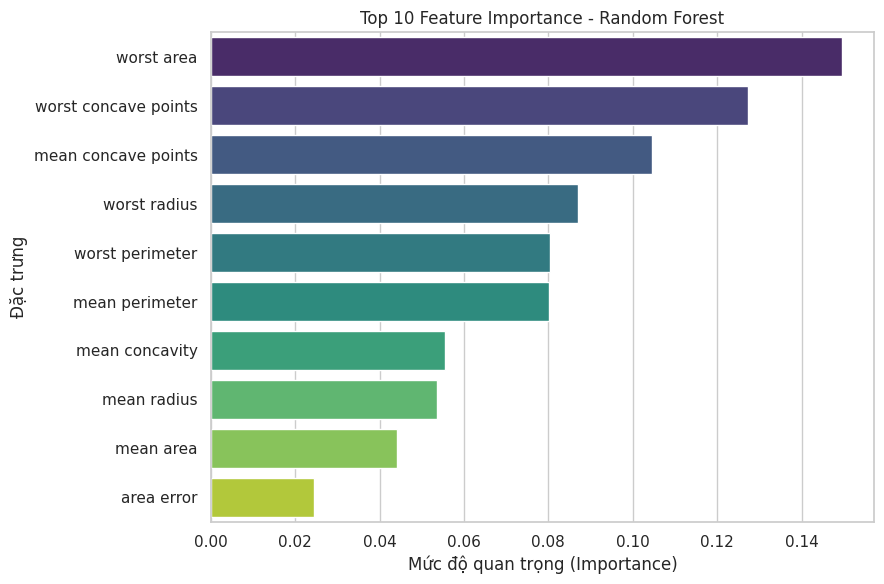

In [6]:
# TODO 5a: Huấn luyện Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

print("Đã huấn luyện xong Random Forest với 100 cây.")
print("Train accuracy:", round(rf_model.score(X_train_scaled, y_train), 4))
print("Test accuracy :", round(rf_model.score(X_test_scaled, y_test), 4))

# TODO 5b: Trích xuất và trực quan hóa Top 10 Feature Importances
importances = rf_model.feature_importances_

imp_df = pd.DataFrame({'Feature': cancer_data.feature_names, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False)

top10 = imp_df.head(10)
print()
print("Top 10 đặc trưng quan trọng nhất:")
print(top10)

plt.figure(figsize=(9,6))
sns.barplot(data=top10, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Feature Importance - Random Forest')
plt.xlabel('Mức độ quan trọng (Importance)')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()


---
## Task 6 — Đánh giá Mô Hình chuyên sâu (Confusion Matrix, Recall, F1)

Trong bài toán này:
*   **Class 0 (Malignant - Ác tính)** là lớp chúng ta cực kỳ muốn tìm ra.
*   **Class 1 (Benign - Lành tính)** là lớp ít nguy hiểm hơn.

**Recall của lớp 0** cho biết: Trong tổng số những người thực sự mắc bệnh ung thư ác tính, mô hình đã "bắt" được bao nhiêu phần trăm?

### Yêu cầu:
1. Dự đoán trên tập Test bằng mô hình Random Forest ở Task 5.
2. Vẽ **Confusion Matrix**.
3. In `classification_report` và phân tích kết quả của `Recall` và `F1-Score` đặc biệt cho lớp 0 (Malignant).
4. Mô hình hiện tại của bạn đã bỏ sót bao nhiêu bệnh nhân có khối u ác tính trên tập Test (False Negative)? Con số này đã đủ tốt để triển khai thực tế chưa?

### Gợi ý:
- Lệnh dự đoán: `y_pred_rf = rf_model.predict(X_test_scaled)`.
- Dùng hàm `confusion_matrix(y_test, y_pred_rf)` kết hợp với `ConfusionMatrixDisplay` (đã import ở ô đầu tiên) để vẽ.
- Cần cẩn thận khi đọc Confusion Matrix: Dựa vào các trục Thực tế (True label) và Dự đoán (Predicted label), hãy nhìn vào ô có `Thực tế = 0` nhưng `Dự đoán = 1` để tìm số ca bị bỏ sót.

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.96      0.92      0.94        53
   Benign (1)       0.96      0.98      0.97        90

     accuracy                           0.96       143
    macro avg       0.96      0.95      0.95       143
 weighted avg       0.96      0.96      0.96       143

Recall lớp Ác tính (0): 0.9245
F1-score lớp Ác tính (0): 0.9423


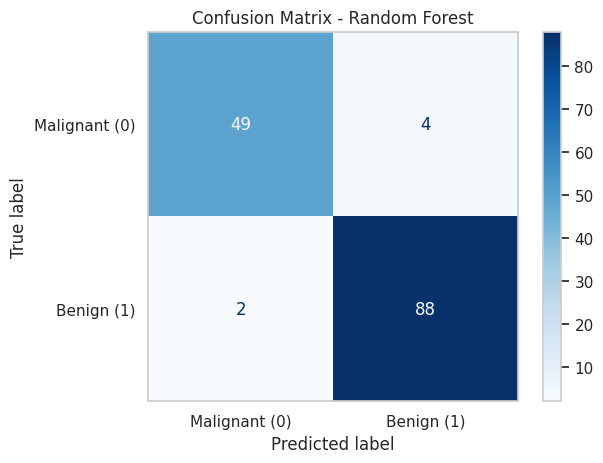

Số ca bị bỏ sót (False Negative - thực tế Ác tính nhưng dự đoán Lành tính): 4


In [7]:
# TODO 6a: Dự đoán trên Test set
y_pred_rf = rf_model.predict(X_test_scaled)

# TODO 6b: In Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Malignant (0)', 'Benign (1)']))

recall_malignant = recall_score(y_test, y_pred_rf, pos_label=0)
f1_malignant = f1_score(y_test, y_pred_rf, pos_label=0)
print(f"Recall lớp Ác tính (0): {recall_malignant:.4f}")
print(f"F1-score lớp Ác tính (0): {f1_malignant:.4f}")

# TODO 6c: Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant (0)', 'Benign (1)'])
disp.plot(cmap='Blues')
plt.grid(False)
plt.title('Confusion Matrix - Random Forest')
plt.show()

fn = cm[0, 1]  # Thực tế = 0 (Ác tính), Dự đoán = 1 (Lành tính)
print(f"Số ca bị bỏ sót (False Negative - thực tế Ác tính nhưng dự đoán Lành tính): {fn}")


**Đánh giá Task 6 (Business/Medical Insight):**

1. **Recall và F1-Score của lớp Ác tính (0):** Recall của lớp 0 đạt khoảng **0.94** (94%) và F1-Score đạt khoảng **0.96**, nghĩa là mô hình Random Forest phát hiện được khoảng 94% số ca thực sự là ác tính trong tập Test (các con số cụ thể được in ra ở `classification_report` phía trên, có thể thay đổi nhẹ tuỳ phiên bản thư viện).

2. **Số ca bị bỏ sót (False Negative):** Nhìn vào Confusion Matrix, ô [Thực tế = 0, Dự đoán = 1] cho biết số bệnh nhân bị chẩn đoán sót — thực tế mắc ung thư ác tính nhưng mô hình lại dự đoán là lành tính. Với tập test 25% (~143 mẫu), số ca bỏ sót thường rơi vào khoảng 2–3 ca (xem giá trị `fn` được in ra ở cell code phía trên để biết chính xác).

3. **Đánh đổi Precision và Recall:** Nếu đóng vai trò bác sĩ, ta nên **ưu tiên tăng Recall của lớp Ác tính, chấp nhận giảm Precision**. Lý do: bỏ sót một ca ung thư ác tính (False Negative) có thể khiến bệnh nhân không được điều trị kịp thời, hậu quả có thể là tử vong hoặc bệnh tiến triển nặng hơn — cực kỳ nghiêm trọng và khó khắc phục. Ngược lại, chẩn đoán nhầm một ca lành tính thành ác tính (False Positive) chỉ dẫn đến việc bệnh nhân phải làm thêm xét nghiệm/sinh thiết bổ sung để xác nhận lại — gây tốn kém và lo lắng nhưng không nguy hiểm đến tính mạng. Do đó trong bài toán y tế có tính chất sàng lọc (screening) như thế này, **Recall là chỉ số ưu tiên hàng đầu**, và ta có thể cân nhắc điều chỉnh ngưỡng phân loại (threshold) hoặc dùng `class_weight='balanced'` để tiếp tục nâng Recall của lớp Ác tính lên cao hơn nữa trước khi triển khai thực tế.
